
# Are like-minded students in one topic still like-minded overall?

**Dataset.** `Survey_Results_UC.csv` — 96 students, 60 Likert-scale statements
(Strongly Disagree ... Strongly Agree) split into four topic blocks of 15 items each:

- **T** — Artificial Intelligence / technology attitudes
- **E** — Education
- **S** — Society / ethics
- **V** — Environment / sustainability

**The idea we're testing.** Represent every student as a node. Each student has:

- a **global** response vector (all 60 items)
- four **topic** response vectors (15 items each: T, E, S, V)

For each of these five vector spaces we build a student-similarity graph, run
community detection ("like-minded" clusters) on it, and then ask: **do the
communities a student belongs to in a single-topic graph line up with the
community they belong to in the global graph?**

We compute similarity three ways (Pearson correlation, cosine similarity, exact
agreement rate), and we build the graph two ways: the **full** weighted graph
(every positive-similarity pair is an edge, nothing cut) and two **sparsified**
versions (**k-NN** and a matching-density **threshold** graph), so we can see
how much the sparsification choice itself changes the answer.


In [1]:

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

pd.set_option('display.width', 140)
np.random.seed(42)



## 1. Load and clean the data

Two quirks in the raw CSV are worth handling explicitly:

1. A few question texts contain literal commas inside quoted fields (e.g. *"...
   encouraged, but not mandatory."*), and the quotes are preceded by a stray
   space, which breaks naive `csv`/`pandas` parsing unless we pass
   `skipinitialspace=True`.
2. Responses are the strings `Strongly Disagree ... Strongly Agree`, plus an
   explicit `"No Comments"` option and true blanks — both of which we treat as
   missing (`NaN`), not as a neutral response.


In [2]:

LIKERT_MAP = {
    'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5,
}

def load_data(path):
    df = pd.read_csv(path, skipinitialspace=True, encoding='utf-8-sig')
    cols = ['id'] + [c.split('.')[0].strip() for c in df.columns[1:]]
    df.columns = cols
    resp = df.iloc[:, 1:].apply(lambda s: s.str.strip())
    coded = resp.replace(LIKERT_MAP)
    coded = coded.where(coded.isin([1, 2, 3, 4, 5]), np.nan)  # 'No Comments' / blank -> NaN
    coded = coded.apply(pd.to_numeric, errors='coerce')
    return pd.concat([df['id'], coded], axis=1)

data = load_data('Survey_Results_UC.csv')
print('students x columns:', data.shape)
data.head()


students x columns: (96, 61)


,id,T01,T02,T03,T04,T05,T06,T07,T08,T09,...,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15
0,11,4.0,4.0,3.0,5.0,5.0,4.0,4.0,2.0,3.0,...,3.0,4.0,3.0,5.0,3.0,3.0,3.0,4.0,4.0,3.0
1,12,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,...,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0
2,13,4.0,5.0,3.0,2.0,5.0,4.0,5.0,4.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,4.0
3,14,3.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0
4,16,3.0,4.0,5.0,5.0,1.0,5.0,5.0,4.0,3.0,...,4.0,5.0,4.0,5.0,3.0,4.0,3.0,5.0,5.0,4.0



## 2. Topic groups and the completeness problem

Some students skipped entire topic blocks or the whole survey. Those rows carry
no signal for the blocks they skipped, so we restrict to the **68 students with
zero missing answers anywhere** — this keeps the same set of nodes in every
graph (global and all four topics), which is required to compare communities
across them fairly.


In [3]:

TOPIC_COLS = {t: [c for c in data.columns if c.startswith(t)] for t in ['T', 'E', 'S', 'V']}
GLOBAL_COLS = TOPIC_COLS['T'] + TOPIC_COLS['E'] + TOPIC_COLS['S'] + TOPIC_COLS['V']

for t, cols in TOPIC_COLS.items():
    n_complete = data[cols].notna().all(axis=1).sum()
    print(f'topic {t}: {len(cols)} items, {n_complete}/{len(data)} students answered all of them')

complete_mask = data[GLOBAL_COLS].notna().all(axis=1)
print(f'\ncommon cohort (complete on all 60 items): {complete_mask.sum()}/{len(data)} students')
print('excluded student ids:', data.loc[~complete_mask, 'id'].tolist())

cohort = data.loc[complete_mask].reset_index(drop=True)
N = len(cohort)
SPACES = {'global': GLOBAL_COLS, **TOPIC_COLS}


topic T: 15 items, 83/96 students answered all of them
topic E: 15 items, 81/96 students answered all of them
topic S: 15 items, 78/96 students answered all of them
topic V: 15 items, 81/96 students answered all of them

common cohort (complete on all 60 items): 68/96 students
excluded student ids: [12, 19, 24, 30, 32, 39, 40, 42, 44, 60, 68, 69, 73, 77, 78, 79, 81, 84, 87, 92, 93, 95, 102, 103, 118, 120, 123, 125]



## 3. Three ways to measure "like-minded"

- **Pearson correlation** — do two students trend the same direction across
  items, regardless of how extreme their ratings are? Mathematically undefined
  for a student who rated every item in a block identically (zero variance) —
  we map that case to similarity 0 rather than dropping the student.
- **Cosine similarity** — angle between the raw 1–5 rating vectors.
- **Agreement rate** — fraction of items on which two students picked the exact
  same category. The most literal reading of "like-minded."


In [4]:

def pearson_sim(X):
    with np.errstate(invalid='ignore'):
        S = np.corrcoef(X)
    S = np.nan_to_num(S, nan=0.0)
    np.fill_diagonal(S, 1.0)
    return S

def cosine_sim(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Xn = X / norms
    return Xn @ Xn.T

def agreement_sim(X):
    n = X.shape[0]
    S = np.zeros((n, n))
    for i in range(n):
        S[i] = (X == X[i]).mean(axis=1)
    return S

METRICS = {'pearson': pearson_sim, 'cosine': cosine_sim, 'agreement': agreement_sim}

sim_matrices = {}
for space_name, cols in SPACES.items():
    X = cohort[cols].values.astype(float)
    for metric_name, fn in METRICS.items():
        sim_matrices[(space_name, metric_name)] = fn(X)

print(f'{len(sim_matrices)} similarity matrices computed (5 spaces x 3 metrics), each {N}x{N}')


15 similarity matrices computed (5 spaces x 3 metrics), each 68x68



## 4. Building the graph, two ways

- **Full** — every pair of students with a positive similarity gets an edge,
  weighted by that similarity. Nothing is cut.
- **k-NN (k=8)** — every student links to their 8 most similar peers (edges
  symmetrised).
- **Threshold** — keep the globally highest-similarity pairs, with the cutoff
  chosen so the edge count matches the k-NN graph (a fair comparison between
  the two sparsification strategies).


In [5]:

def full_graph(sim):
    n = sim.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    iu = np.triu_indices(n, k=1)
    for i, j in zip(*iu):
        w = sim[i, j]
        if w > 0:
            G.add_edge(int(i), int(j), weight=float(w))
    return G

def knn_graph(sim, k=8):
    n = sim.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        row = sim[i].copy()
        row[i] = -np.inf
        for j in np.argsort(row)[-k:]:
            w = sim[i, j]
            if w > 0:
                if G.has_edge(i, j):
                    G[i][j]['weight'] = max(G[i][j]['weight'], w)
                else:
                    G.add_edge(i, j, weight=float(w))
    return G

def threshold_graph(sim, target_edges):
    n = sim.shape[0]
    iu = np.triu_indices(n, k=1)
    vals = sim[iu]
    order = np.argsort(vals)[::-1]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    count = 0
    for idx in order:
        if count >= target_edges:
            break
        w = vals[idx]
        if w <= 0:
            break
        i, j = int(iu[0][idx]), int(iu[1][idx])
        G.add_edge(i, j, weight=float(w))
        count += 1
    return G

K = 8
graphs = {}
for (space_name, metric_name), sim in sim_matrices.items():
    Gf = full_graph(sim)
    Gk = knn_graph(sim, k=K)
    Gt = threshold_graph(sim, target_edges=Gk.number_of_edges())
    graphs[(space_name, metric_name, 'full')] = Gf
    graphs[(space_name, metric_name, 'knn')] = Gk
    graphs[(space_name, metric_name, 'threshold')] = Gt

rows = []
for (space, metric, gtype), G in graphs.items():
    rows.append({'space': space, 'metric': metric, 'graph': gtype, 'edges': G.number_of_edges(),
                 'density': round(nx.density(G), 3),
                 'isolates': sum(1 for n in G.nodes() if G.degree(n) == 0)})
pd.DataFrame(rows).pivot_table(index=['metric', 'graph'], columns='space', values=['edges', 'isolates'])


edges                                 isolates                        
space                     E       S       T       V  global        E     S    T     V global
metric    graph                                                                             
agreement full       2263.0  2253.0  2269.0  2228.0  2278.0      0.0   0.0  0.0   0.0    0.0
          knn         390.0   408.0   379.0   422.0   421.0      0.0   0.0  0.0   0.0    0.0
          threshold   390.0   408.0   379.0   422.0   421.0      3.0   7.0  1.0   6.0    8.0
cosine    full       2278.0  2278.0  2278.0  2278.0  2278.0      0.0   0.0  0.0   0.0    0.0
          knn         396.0   477.0   427.0   481.0   473.0      0.0   0.0  0.0   0.0    0.0
          threshold   396.0   477.0   427.0   481.0   473.0      9.0  23.0  7.0  17.0   17.0
pearson   full       2068.0  1145.0  1541.0   989.0  2147.0      1.0   5.0  1.0  10.0    0.0
          knn         398.0   333.0   369.0   295.0   434.0      1.0   5.0  1.0  10.0    0.0
          threshold   398.0   333.0   369.0   295.0   434.0      8.0   5.0  3.0  10.0    9.0


**Cosine similarity is always positive here** (all ratings are on a 1–5 scale,
so no vector ever points in an "opposite" direction), which makes the *full*
cosine graph nearly or exactly complete (density ≈ 1.0) — but k-NN/threshold
still pick out each node's *relatively* most-similar peers, so cosine behaves
fine once sparsified (see the community counts below).

**Pearson has isolates** in every version, worst on S and V: students who
rated every item in that topic identically have an undefined (zero-variance)
correlation with everyone, so they end up with no edges regardless of how the
graph is built. This is a property of the metric, not of sparsification.



## 5. Community detection (Louvain modularity maximisation)

Run Louvain on all 45 graphs (5 spaces x 3 metrics x 3 graph-building
strategies), `seed=42` for reproducibility.


In [6]:

partitions = {}
modularity = {}
summary_rows = []

for key, G in graphs.items():
    comms = nx.community.louvain_communities(G, weight='weight', seed=42)
    label = np.zeros(N, dtype=int)
    for cid, nodes in enumerate(comms):
        for node in nodes:
            label[node] = cid
    partitions[key] = label
    total_w = sum(w for _, _, w in G.edges(data='weight', default=0))
    modularity[key] = nx.community.modularity(G, comms, weight='weight') if total_w > 0 else float('nan')
    space, metric, gtype = key
    summary_rows.append({'space': space, 'metric': metric, 'graph': gtype, 'n_communities': len(comms),
                          'modularity': round(modularity[key], 3)})

summary_df = pd.DataFrame(summary_rows)
summary_df.pivot_table(index=['metric', 'graph'], columns='space', values='n_communities')


space                   E     S     T     V  global
metric    graph                                    
agreement full        2.0   2.0   2.0   2.0     2.0
          knn         4.0   4.0   5.0   4.0     3.0
          threshold   8.0  11.0   5.0  11.0    11.0
cosine    full        1.0   1.0   1.0   1.0     1.0
          knn         4.0   4.0   5.0   5.0     4.0
          threshold  14.0  26.0  11.0  22.0    22.0
pearson   full        4.0  10.0   5.0  15.0     3.0
          knn         6.0  11.0   6.0  15.0     5.0
          threshold  14.0  10.0   8.0  15.0    14.0


Confirms it: cosine collapses to a **single** community only in the `full`
graph (no contrast to split on when almost every weight is similarly high and
every pair is connected); under `knn`/`threshold` it produces real,
multi-community structure, because sparsification keeps only each node's
*relatively* strongest ties, which restores contrast even when the raw
similarity values are all positive and close together. **We exclude only the
`(cosine, full)` cells** from the comparison below as undefined/uninformative
— everything else is kept.



## 6. Core question: does a topic's "like-minded" grouping survive into the global grouping?

For every (metric, graph-building) combination except `(cosine, full)`,
compare each topic's partition to the global partition using:

- **Adjusted Rand Index (ARI)** — agreement between two partitions, corrected
  for chance; 0 = no better than random, 1 = identical.
- **Normalized Mutual Information (NMI)** — how much knowing one partition
  tells you about the other; 0 = independent, 1 = identical.


In [7]:

rows = []
for metric_name in METRICS:
    for graph_type in ['full', 'knn', 'threshold']:
        if metric_name == 'cosine' and graph_type == 'full':
            continue
        global_label = partitions[('global', metric_name, graph_type)]
        for topic in ['T', 'E', 'S', 'V']:
            topic_label = partitions[(topic, metric_name, graph_type)]
            rows.append({
                'metric': metric_name, 'graph': graph_type, 'topic': topic,
                'ARI': adjusted_rand_score(global_label, topic_label),
                'NMI': normalized_mutual_info_score(global_label, topic_label),
            })

comparison_df = pd.DataFrame(rows)
print('Adjusted Rand Index (topic partition vs. global partition):')
display(comparison_df.pivot_table(index=['metric', 'graph'], columns='topic', values='ARI').round(3))


Adjusted Rand Index (topic partition vs. global partition):


topic                    E      S      T      V
metric    graph                                
agreement full       0.210  0.625  0.091  0.775
          knn        0.135  0.460  0.138  0.384
          threshold  0.187  0.350  0.175  0.248
cosine    knn        0.126  0.106  0.099  0.012
          threshold  0.126  0.168  0.024  0.077
pearson   full       0.171 -0.002  0.115 -0.015
          knn        0.119  0.045  0.092 -0.006
          threshold  0.234 -0.017  0.230 -0.010

In [8]:

CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
TOPIC_COLOR = {'T': CAT[0], 'E': CAT[1], 'S': CAT[2], 'V': CAT[3]}
SURFACE, INK, INK2, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': False, 'font.size': 10,
})


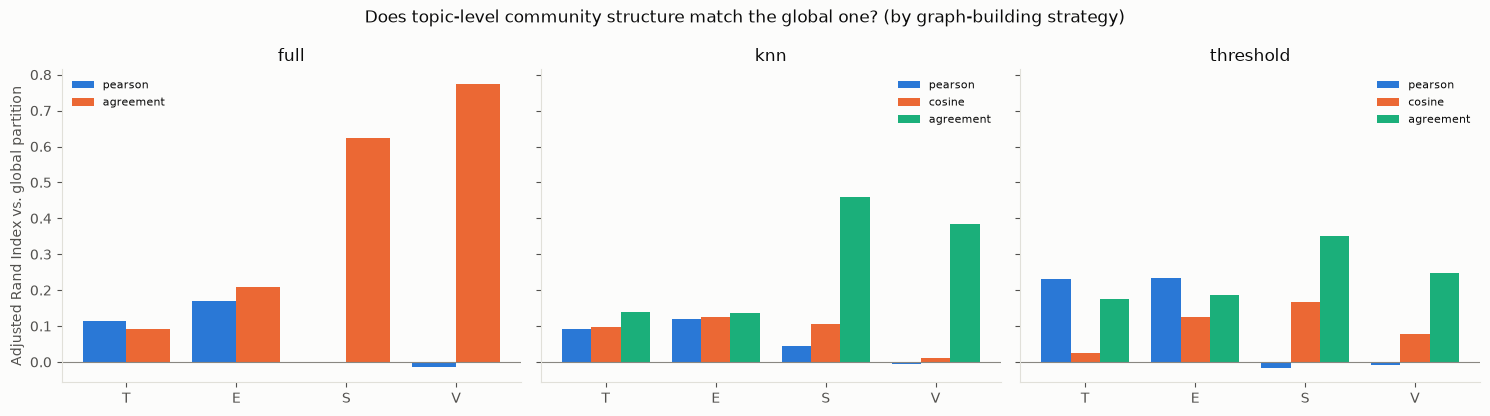

In [9]:

topics = ['T', 'E', 'S', 'V']
graph_types = ['full', 'knn', 'threshold']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, gtype in zip(axes, graph_types):
    sub_metrics = [m for m in METRICS if not (m == 'cosine' and gtype == 'full')]
    x = np.arange(len(topics))
    width = 0.8 / len(sub_metrics)
    for i, m in enumerate(sub_metrics):
        sub = comparison_df[(comparison_df.metric == m) & (comparison_df.graph == gtype)].set_index('topic').loc[topics]
        ax.bar(x + (i - (len(sub_metrics) - 1) / 2) * width, sub['ARI'], width=width, label=m, color=CAT[i])
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(topics)
    ax.set_title(gtype)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Adjusted Rand Index vs. global partition')
fig.suptitle('Does topic-level community structure match the global one? (by graph-building strategy)')
fig.tight_layout()
plt.show()



**The S/V-more-than-T/E pattern survives sparsification, but gets weaker.**
Under `agreement`, the full graph gives the strongest signal (S=0.62, V=0.78
vs. T=0.09, E=0.21); k-NN and threshold preserve the same *ordering* (S and V
still clearly ahead of T and E) but at lower magnitude — sparsification
throws away some of the weighted signal that the full graph keeps. `pearson`
stays weak/inconsistent everywhere (its isolates problem isn't fixed by
sparsifying, since a truly zero-similarity student stays disconnected either
way). `cosine`, once it has any structure to compare (k-NN/threshold only),
shows the weakest, noisiest persistence of the three metrics.

**Takeaway:** the direction of the finding (society/environment attitudes
predict overall grouping much better than tech/education attitudes do) is
robust to how you build the graph. The exact numbers are not — the full
(unsparsified) graph gives the clearest version of the effect, so that's what
we use for the visualizations in Section 8.



## 7. Consensus vs. controversy: which topics actually have opinions to cluster on?

A topic where 90% of students pick "Strongly Agree" has no real attitude
variation to build communities around. Item variance tells us which topics are
worth this kind of analysis at all, and helps explain the pattern above.


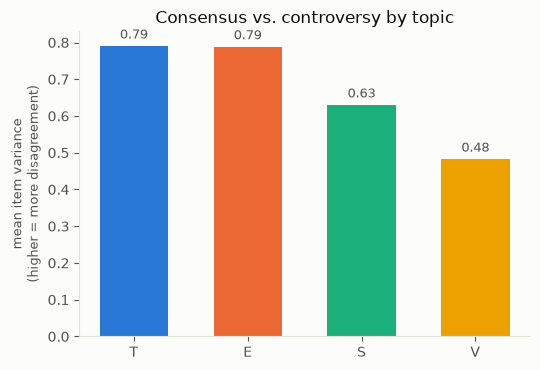

most controversial items (highest variance):
E04    1.382572
E09    1.201712
E02    1.197542
T08    1.161326
E03    1.084065
dtype: float64

most consensus items (lowest variance):
V13    0.246488
E15    0.257243
S09    0.281607
S05    0.306190
E10    0.321335
dtype: float64


In [10]:

item_var = cohort[GLOBAL_COLS].astype(float).var(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
vals = [item_var[TOPIC_COLS[t]].mean() for t in topics]
bars = ax.bar(topics, vals, color=[TOPIC_COLOR[t] for t in topics], width=0.6)
ax.set_ylabel('mean item variance\n(higher = more disagreement)', fontsize=9)
ax.set_title('Consensus vs. controversy by topic')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', color=INK2, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

print('most controversial items (highest variance):')
print(item_var.sort_values(ascending=False).head(5))
print('\nmost consensus items (lowest variance):')
print(item_var.sort_values().head(5))



**T and E are where the real disagreement lives**; V (environment) and S are
close to unanimous. This reframes the Section 6 finding: it's not that
students are more "like-minded" about society/environment in some deep sense —
it's that **there's less room to disagree there in the first place**, so
whatever small variation exists lines up more closely with a person's *general*
disposition (their global grouping). T and E, having genuine spread, are where
topic-specific opinions can actually diverge from that general disposition —
which is also exactly why their community structure looks more independent of
the global one.



## 8. Seeing it: one graph per strategy, five colorings each, one big image at a time

For each graph-building strategy (full, k-NN, threshold), this draws the
**global agreement-rate graph once** — one fixed layout — and recolors its
nodes five times: by the global community assignment, then by each topic's own
community assignment. Because the layout doesn't change within a strategy, if
a topic's coloring looks like the global coloring, that topic's like-minded
groups really do match the global ones; if it looks shuffled, they don't.

Each image is its own full-size plot rather than a row of small panels.

(Community labels from Louvain are arbitrary, so before coloring, each topic's
labels are re-matched to whichever global community they overlap most with,
using the Hungarian algorithm — otherwise the colors wouldn't be comparable
across panels. Edge opacity/width is scaled by similarity strength purely for
legibility; every edge is still drawn, none are removed.)


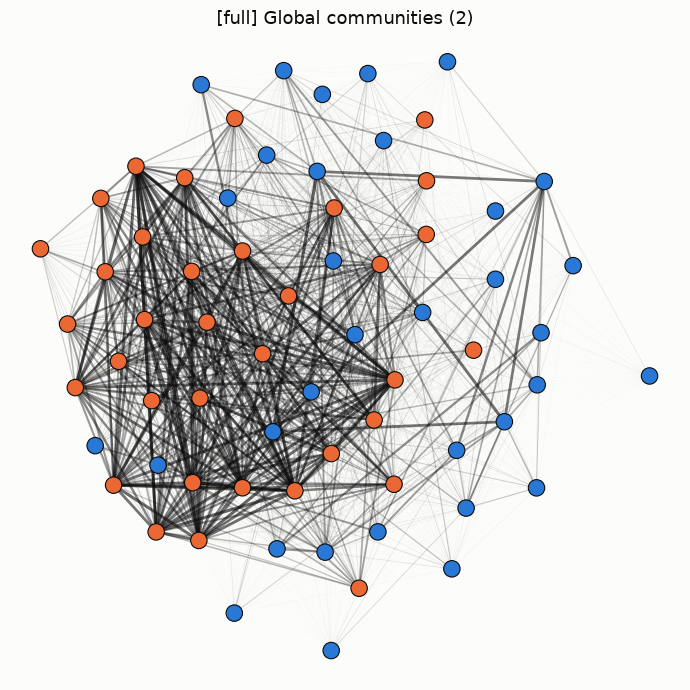

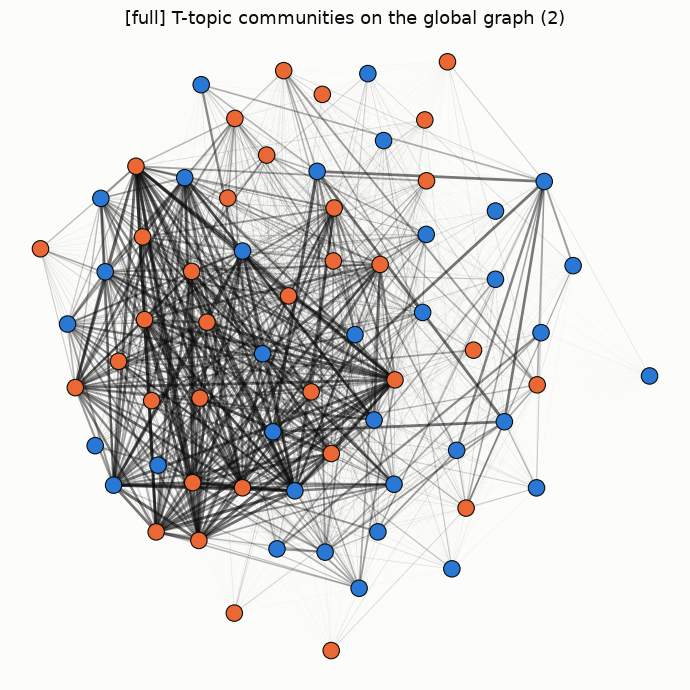

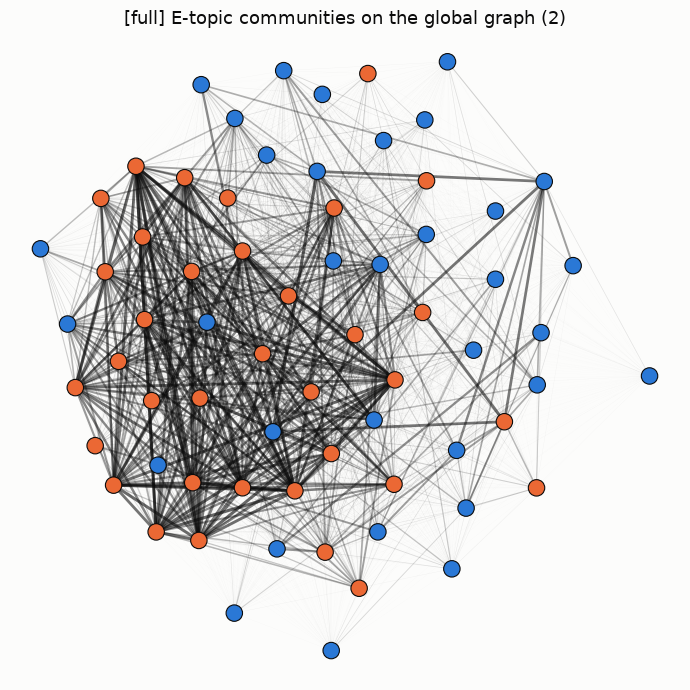

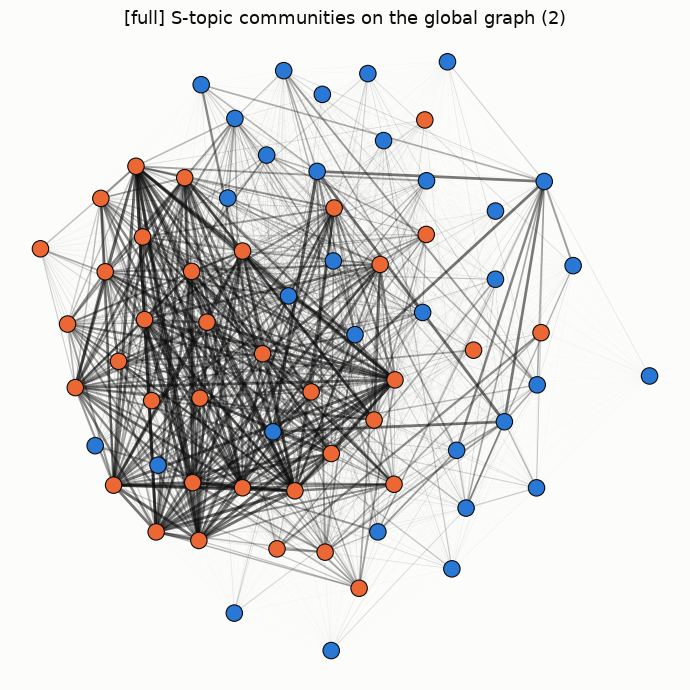

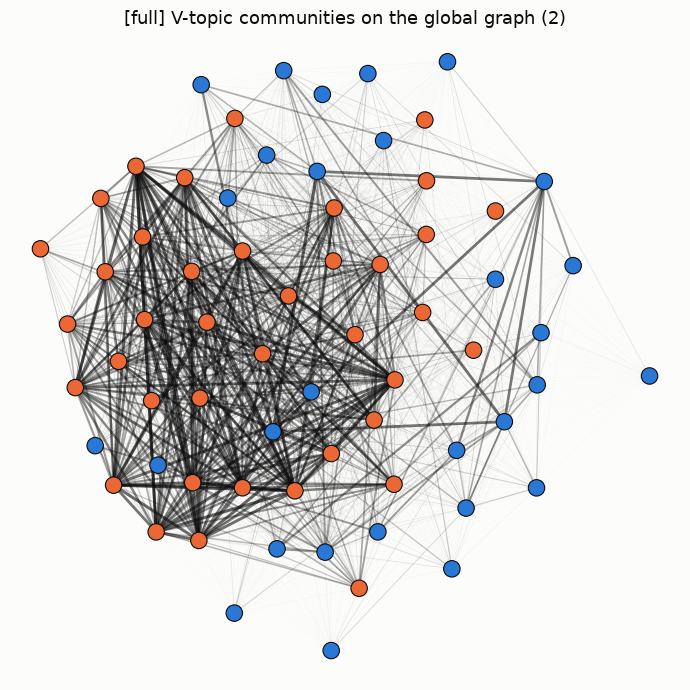

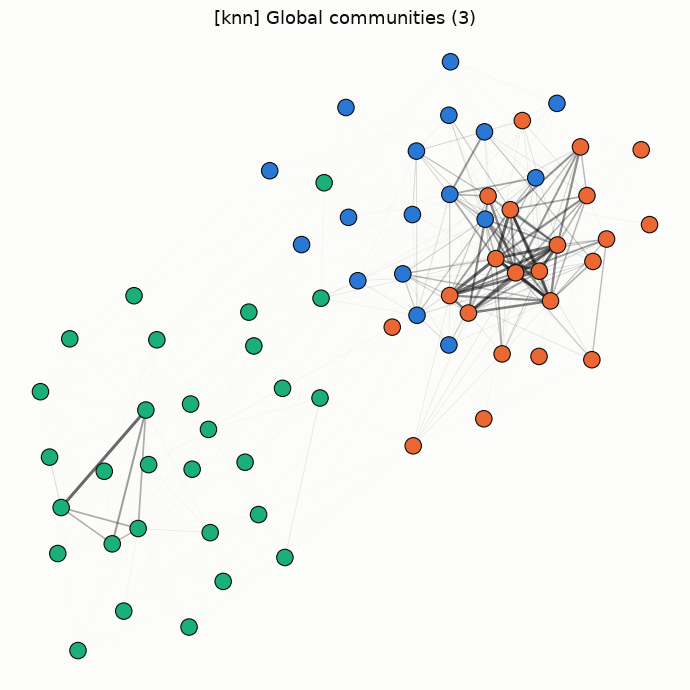

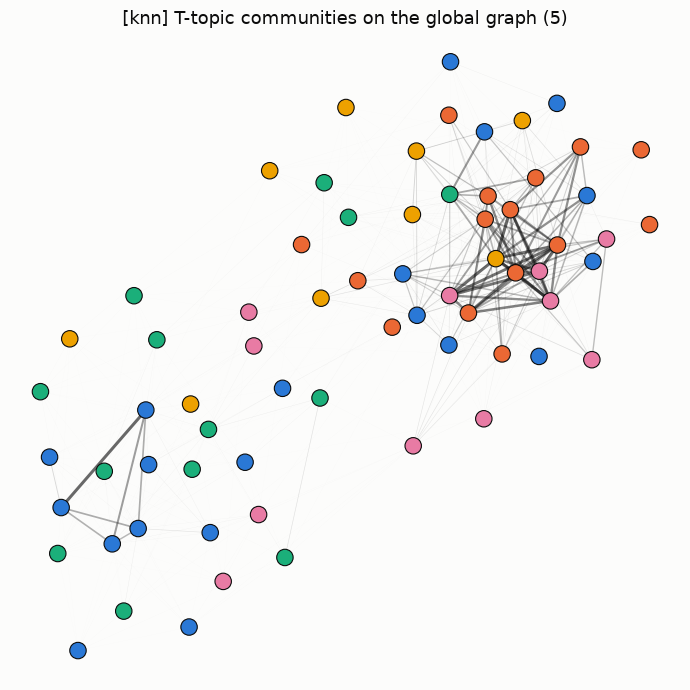

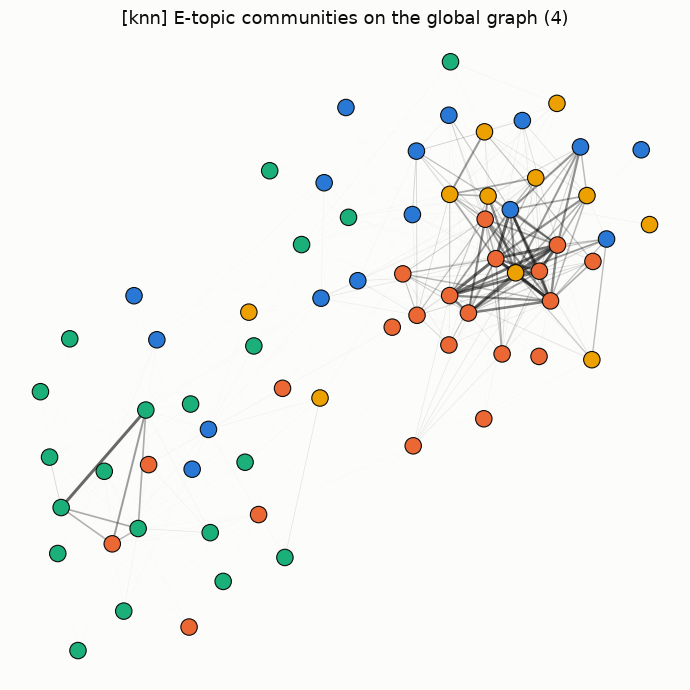

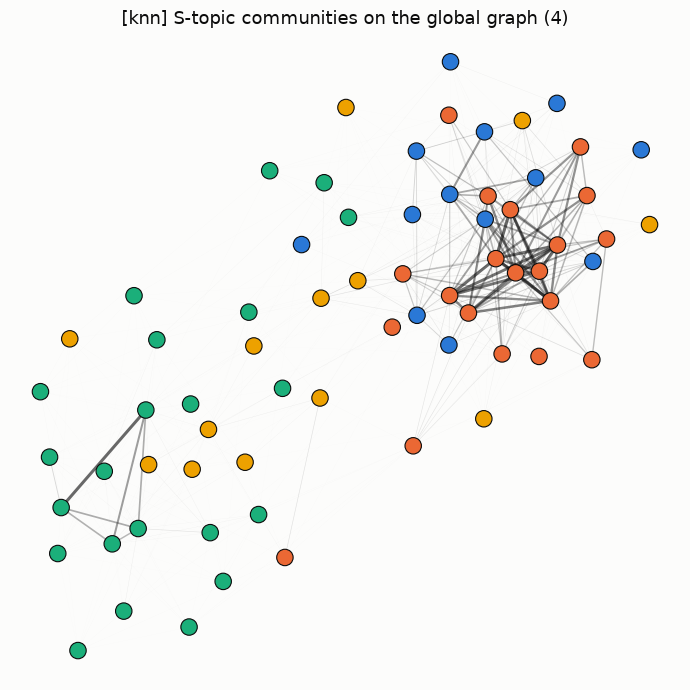

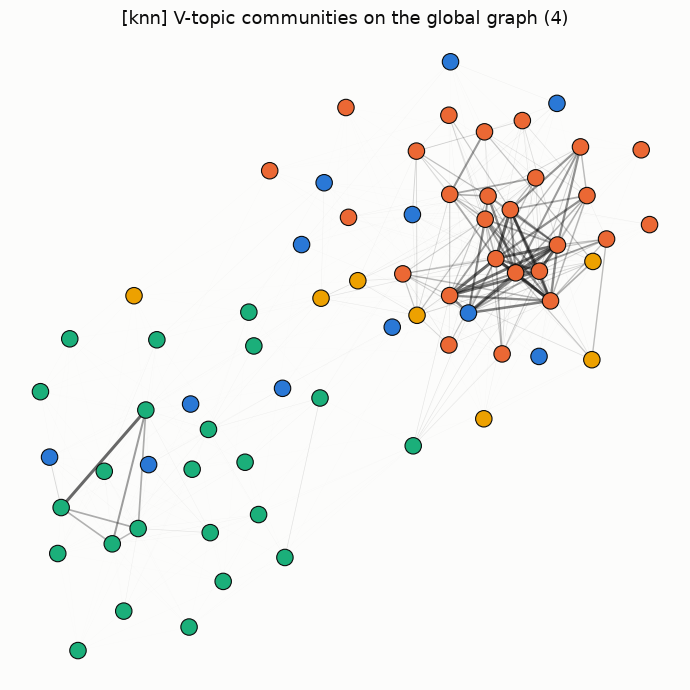

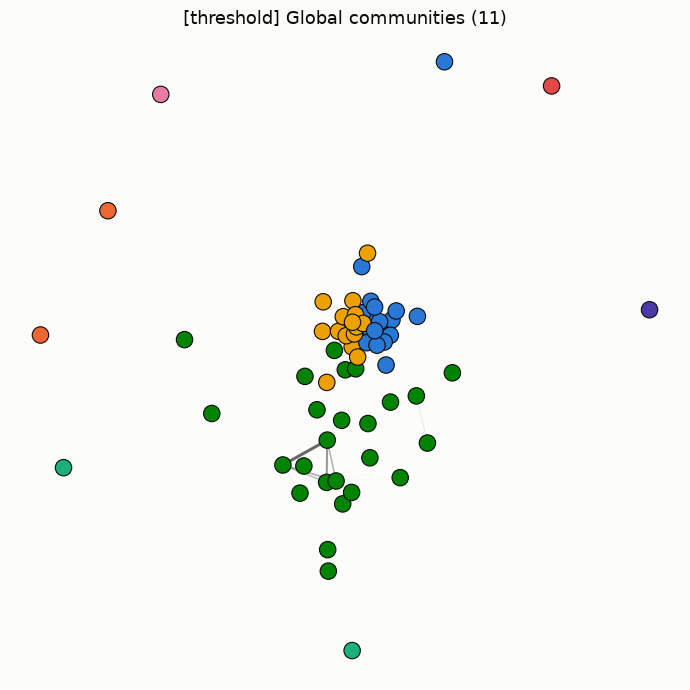

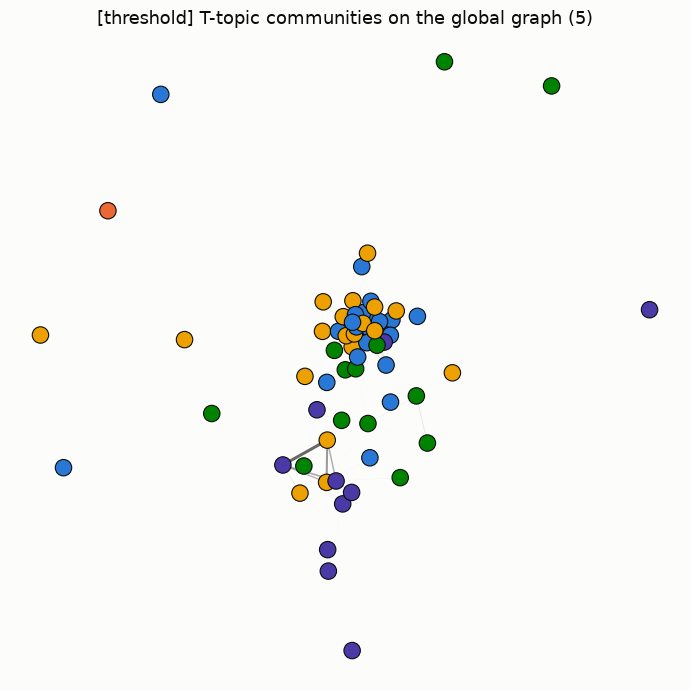

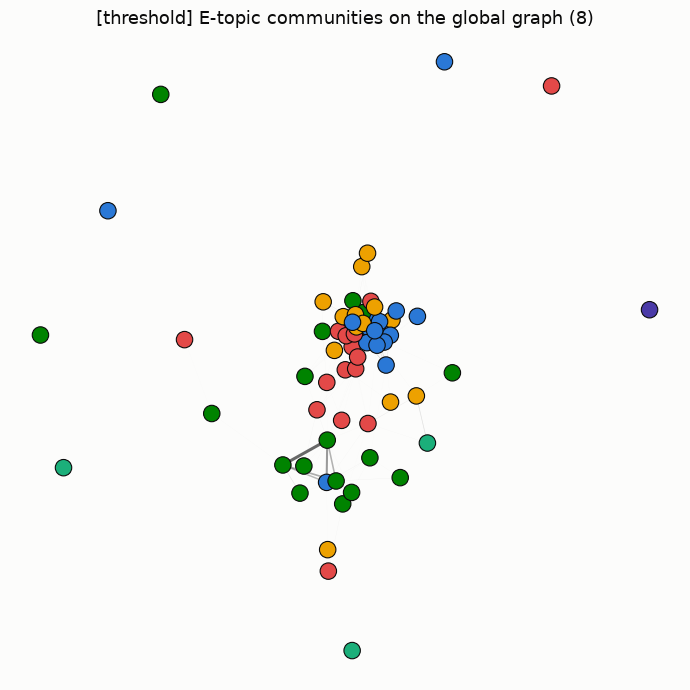

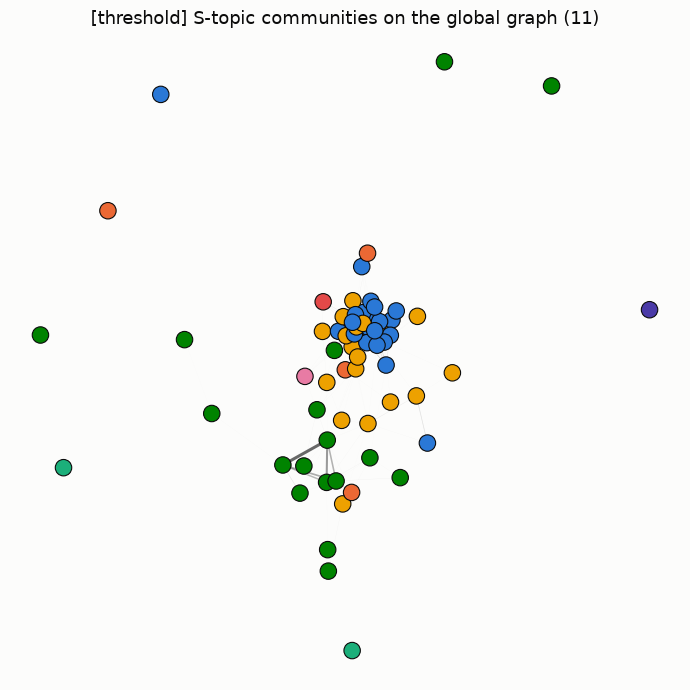

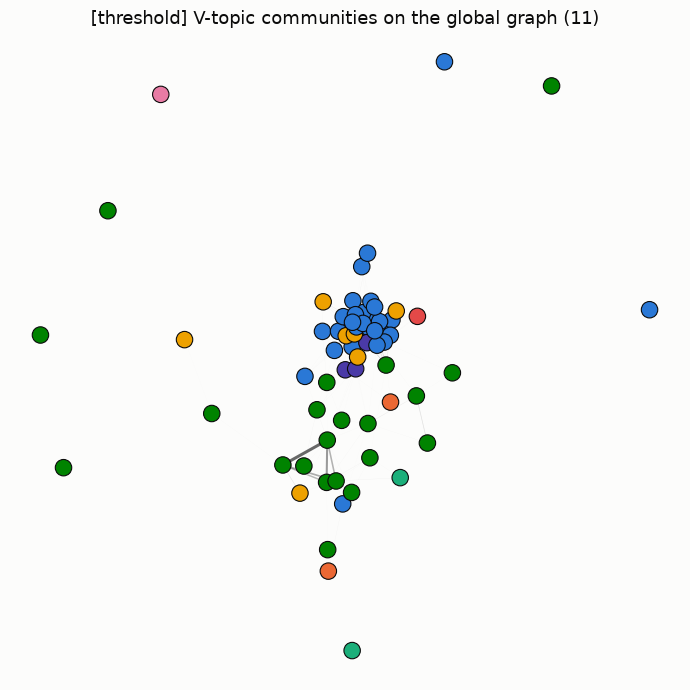

In [11]:

def align_labels(label, reference):
    k = max(label.max(), reference.max()) + 1
    cost = np.zeros((k, k))
    for a in range(k):
        for b in range(k):
            cost[a, b] = -np.sum((label == a) & (reference == b))
    row, col = linear_sum_assignment(cost)
    mapping = dict(zip(row, col))
    return np.array([mapping.get(l, l) for l in label])

def draw_big(G, label, title):
    pos = nx.spring_layout(G, weight='weight', seed=42, k=1.5 / np.sqrt(N))
    edge_list = list(G.edges())
    ws = np.array([G[u][v]['weight'] for u, v in edge_list])
    ranks = ws.argsort().argsort() / max(len(ws) - 1, 1)
    alphas = 0.02 + 0.6 * (ranks ** 6)
    widths = 0.2 + 2.0 * (ranks ** 6)
    fig, ax = plt.subplots(figsize=(7, 7))
    for (u, v), a, w in zip(edge_list, alphas, widths):
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=INK, alpha=a, linewidth=w, zorder=1)
    node_colors = [CAT[label[n] % len(CAT)] for n in G.nodes()]
    xs = [pos[n][0] for n in G.nodes()]
    ys = [pos[n][1] for n in G.nodes()]
    ax.scatter(xs, ys, c=node_colors, s=140, edgecolors=INK, linewidths=0.8, zorder=2)
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    fig.tight_layout()
    plt.show()

for gtype in ['full', 'knn', 'threshold']:
    G_global = graphs[('global', 'agreement', gtype)]
    ref_label = partitions[('global', 'agreement', gtype)]
    aligned = {'global': ref_label}
    for t in topics:
        aligned[t] = align_labels(partitions[(t, 'agreement', gtype)], ref_label)
    draw_big(G_global, aligned['global'], f'[{gtype}] Global communities ({len(set(aligned["global"]))})')
    for t in topics:
        draw_big(G_global, aligned[t], f'[{gtype}] {t}-topic communities on the global graph ({len(set(aligned[t]))})')



Compare `[full] V-topic communities` to `[full] Global communities` — nearly
the same coloring in the same layout, matching ARI 0.78. Compare
`[full] T-topic communities` to the same global image — visibly reshuffled,
matching ARI 0.09. The k-NN and threshold versions show the same qualitative
pattern (V/S closer to Global than T/E) but the layouts are sparser and more
fragmented, especially for `threshold`, which — as seen in Section 6 — throws
away some of the persistence signal the full graph preserves.



## 9. Signed network: are the communities actual opposing camps, or just gradations of agreement?

Everything so far only used *positive* similarity — an edge meant "these two
agree," and the absence of an edge meant "no strong relationship." Pearson
correlation can go negative, though, which lets us ask a sharper question:
when two students don't just fail to agree but actively **trend in opposite
directions**, is there real structural polarization (opposing camps, in the
sense of social balance theory) underneath the softer "communities" from
Section 5–6, or are those communities merely "more similar" vs. "less
similar" with no real opposition involved?


In [12]:

neg_rows = []
for space in SPACES:
    A = sim_matrices[(space, 'pearson')]
    iu = np.triu_indices(N, k=1)
    vals = A[iu]
    neg_rows.append({'space': space, 'negative_edges': int((vals < 0).sum()),
                      'total_pairs': len(vals), 'fraction_negative': round((vals < 0).mean(), 3),
                      'most_negative': round(vals.min(), 3)})
pd.DataFrame(neg_rows)


,space,negative_edges,total_pairs,fraction_negative,most_negative
0,global,130,2278,0.057,-0.359
1,T,615,2278,0.270,-0.704
2,E,140,2278,0.061,-0.520
3,S,785,2278,0.345,-0.670
4,V,576,2278,0.253,-0.671



Counter to what Section 7 might suggest, **S and V don't have fewer negative
edges than T** — if anything they have more (S: 35% of pairs negatively
correlated, V: 25%, vs. T: 27%, E: only 6%, global: 6%). Low overall item
variance doesn't mean no opposition: a small dissenting minority that
consistently disagrees with an otherwise-unanimous majority produces *strong*
negative correlations even on a "consensus" topic — variance alone (Section 7)
can't tell majority-vs-minority opposition apart from everyone-independently
noisy disagreement (which is closer to what seems to be happening on E).



**Structural balance**: a 2-way split is "balanced" if positive edges mostly
fall *within* the two groups and negative edges mostly fall *between* them. We
score any split with

$$\text{balance} = \frac{\sum \text{(positive weight within-group)} + \sum \text{(|negative weight| across-group)}}{\sum |\text{weight}|}$$

— 0.5 is what a random split gets by chance, 1.0 is perfect balance.

Naively maximizing this score is a trap: isolating a single strong dissenter
into their own "group of one" trivially scores ~0.99, because a singleton
group can't have any internal disagreement. That's a real result (this dataset
does have at least one very isolated dissenter globally) but it's not the
"two opposing camps" question we actually want to ask, so we **constrain the
smaller group to at least 10 students** (~15% of the cohort) and search by
local flips, starting from the community split we already found in Section 5.


In [13]:

def balance_score(A, labels):
    same = (labels[:, None] == labels[None, :])
    iu = np.triu_indices(len(labels), k=1)
    w, s = A[iu], same[iu]
    good = np.where(s, np.clip(w, 0, None), np.clip(-w, 0, None))
    return good.sum() / np.abs(w).sum()

def local_search_constrained(A, labels, min_size=10, n_iter=300, seed=0):
    rng = np.random.RandomState(seed)
    labels = labels.copy()
    best = balance_score(A, labels)
    improved, it = True, 0
    while improved and it < n_iter:
        improved = False
        it += 1
        for i in rng.permutation(len(labels)):
            old = labels[i]
            labels[i] = 1 - old
            if min(np.sum(labels == 0), np.sum(labels == 1)) < min_size:
                labels[i] = old
                continue
            s = balance_score(A, labels)
            if s > best + 1e-12:
                best, improved = s, True
            else:
                labels[i] = old
    return labels, best

minority_sets = {}
balance_rows = []
for space in SPACES:
    A = sim_matrices[(space, 'pearson')]
    existing = np.array([0 if l == 0 else 1 for l in partitions[(space, 'agreement', 'full')]])
    existing_score = balance_score(A, existing)
    refined, refined_score = local_search_constrained(A, existing, min_size=10)
    sizes = {0: int((refined == 0).sum()), 1: int((refined == 1).sum())}
    minority_label = min(sizes, key=sizes.get)
    minority_sets[space] = set(np.where(refined == minority_label)[0].tolist())
    balance_rows.append({'space': space, 'existing_partition_balance': round(existing_score, 3),
                          'refined_balance': round(refined_score, 3),
                          'majority_size': sizes[1 - minority_label], 'minority_size': sizes[minority_label]})
pd.DataFrame(balance_rows)


,space,existing_partition_balance,refined_balance,majority_size,minority_size
0,global,0.511,0.773,58,10
1,T,0.514,0.835,58,10
2,E,0.526,0.808,58,10
3,S,0.498,0.786,53,15
4,V,0.497,0.787,56,12



**The similarity-based communities from Section 5 score close to 0.5 —
chance level — on this balance measure, in every space.** They reflect a
gradient of "more similar" vs. "less similar," not real opposition. A
genuinely balanced split does exist, though, once you search for it directly:
a consistent **minority of 10–15 students who actively oppose the majority**,
strongest on T (balance 0.84) and E (0.81), still clearly present on S/V/global
(≈0.77–0.79).


In [14]:

print('minority student ids per space:')
for space, idx in minority_sets.items():
    print(f'  {space}: {sorted(cohort.loc[list(idx), "id"].tolist())}')

all_idx = sorted(set.union(*minority_sets.values()))
membership = pd.DataFrame({space: [i in idx for i in all_idx] for space, idx in minority_sets.items()},
                           index=cohort.loc[all_idx, 'id'].values)
membership['n_spaces'] = membership.sum(axis=1)
print('\nstudents who are in the dissenting minority in the most spaces:')
membership.sort_values('n_spaces', ascending=False).head(8)


minority student ids per space:
  global: [13, 46, 52, 70, 89, 90, 109, 111, 117, 119]
  T: [13, 20, 29, 56, 89, 94, 109, 116, 119, 126]
  E: [35, 36, 43, 46, 85, 108, 109, 111, 117, 119]
  S: [16, 21, 22, 52, 62, 63, 72, 80, 90, 101, 108, 109, 111, 119, 126]
  V: [20, 22, 37, 80, 86, 90, 91, 104, 105, 109, 111, 119]

students who are in the dissenting minority in the most spaces:


,global,T,E,S,V,n_spaces
119,True,True,True,True,True,5
109,True,True,True,True,True,5
111,True,False,True,True,True,4
90,True,False,False,True,True,3
126,False,True,False,True,False,2
13,True,True,False,False,False,2
20,False,True,False,False,True,2
22,False,False,False,True,True,2



Two students — **109 and 119** — land in the dissenting minority in **all
five** spaces (global and all four topics): they are the most consistent
contrarians in the entire cohort, not just on one topic. That's a strong,
specific, falsifiable claim this kind of analysis can make that community
detection alone couldn't.


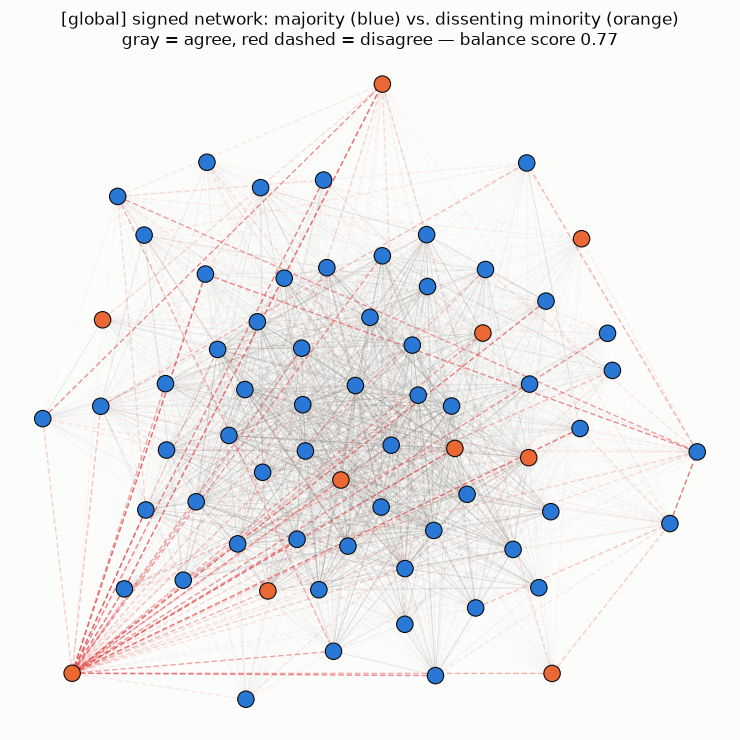

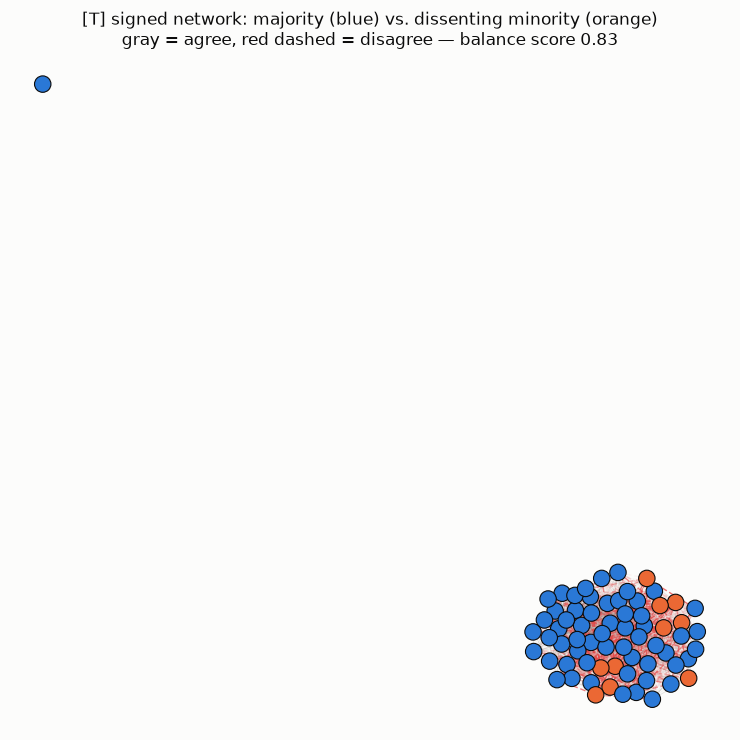

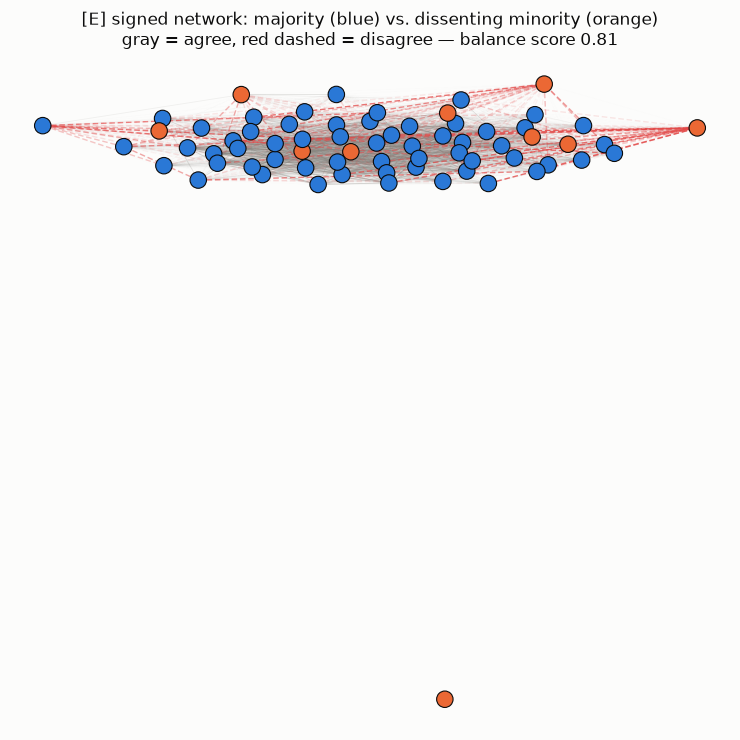

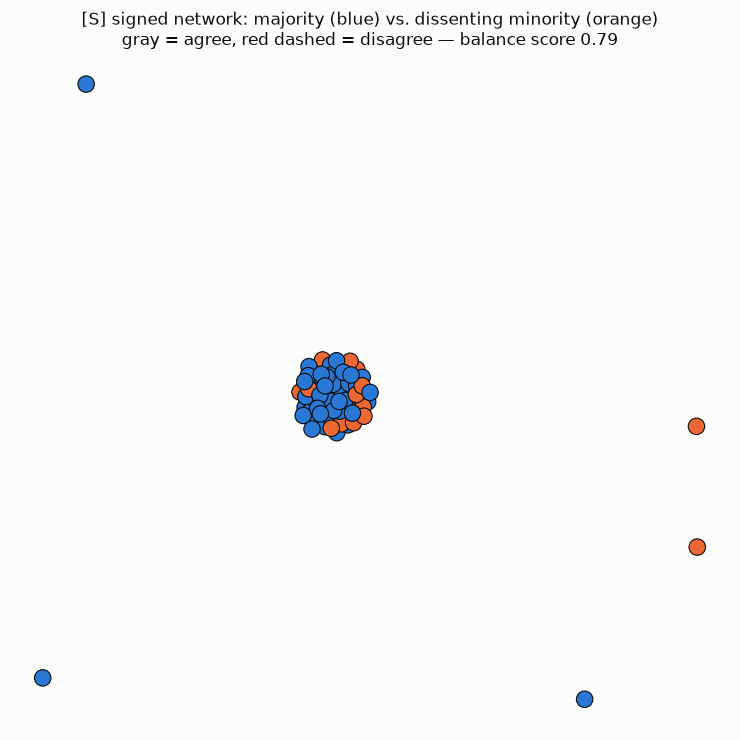

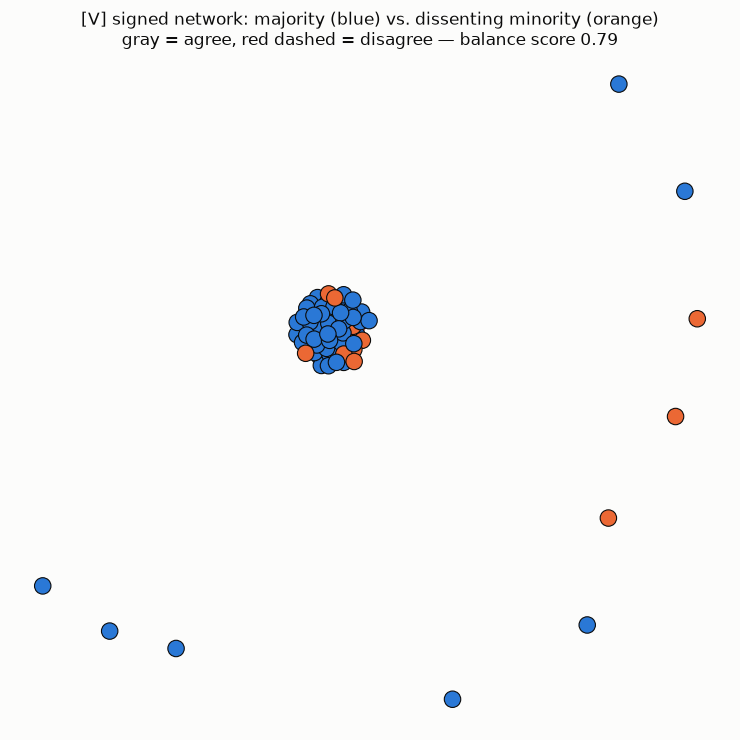

In [15]:

def draw_signed(space, minority_label_set, score):
    A = sim_matrices[(space, 'pearson')]
    Gs = nx.Graph(); Gs.add_nodes_from(range(N))
    Gabs = nx.Graph(); Gabs.add_nodes_from(range(N))
    iu = np.triu_indices(N, k=1)
    for i, j in zip(*iu):
        w = A[i, j]
        if abs(w) > 1e-9:
            Gs.add_edge(int(i), int(j), weight=float(w))
            Gabs.add_edge(int(i), int(j), weight=abs(float(w)))
    pos = nx.spring_layout(Gabs, weight='weight', seed=42, k=1.5 / np.sqrt(N))
    edge_list = list(Gs.edges(data='weight'))
    pos_edges = [(u, v, w) for u, v, w in edge_list if w > 0]
    neg_edges = [(u, v, w) for u, v, w in edge_list if w < 0]

    def scale(ws, floor, ceil, power=4):
        ws = np.abs(np.array(ws))
        ranks = ws.argsort().argsort() / max(len(ws) - 1, 1)
        return floor + (ceil - floor) * (ranks ** power)

    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    if pos_edges:
        alphas = scale([w for _, _, w in pos_edges], 0.01, 0.35)
        for (u, v, w), a in zip(pos_edges, alphas):
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=MUTED, alpha=a, linewidth=0.6, zorder=1)
    if neg_edges:
        alphas = scale([w for _, _, w in neg_edges], 0.05, 0.85)
        for (u, v, w), a in zip(neg_edges, alphas):
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=CAT[7], alpha=a, linewidth=1.0,
                    linestyle=(0, (4, 2)), zorder=2)
    node_colors = [CAT[1] if n in minority_label_set else CAT[0] for n in Gs.nodes()]
    xs = [pos[n][0] for n in Gs.nodes()]; ys = [pos[n][1] for n in Gs.nodes()]
    ax.scatter(xs, ys, c=node_colors, s=140, edgecolors=INK, linewidths=0.8, zorder=3)
    ax.set_title(f'[{space}] signed network: majority (blue) vs. dissenting minority (orange)\n'
                 f'gray = agree, red dashed = disagree — balance score {score:.2f}', fontsize=12)
    ax.axis('off')
    fig.tight_layout()
    plt.show()

for row, space in zip(balance_rows, SPACES):
    draw_signed(space, minority_sets[space], row['refined_balance'])



The red dashed lines make the pattern obvious: the minority students disagree
sharply with much of the majority (long red lines crossing the whole layout),
while the majority mostly agrees internally (dense gray core). This is a
qualitatively different picture from Section 8's community coloring — there,
color meant "somewhat more similar to"; here, color plus edge color together
mean "actively opposed to."



## 10. Persona analysis: are the same students always "typical" or always "contrarian"?

A different, individual-level (not community-level) version of the same
underlying question. For each student in each of the five spaces, compute
**typicality** — their average agreement-rate similarity to everyone else in
that space. High typicality = central, consensus-following; low typicality =
peripheral, atypical.


In [16]:

centrality = pd.DataFrame(index=cohort['id'])
for space, cols in SPACES.items():
    X = cohort[cols].values.astype(float)
    S = sim_matrices[(space, 'agreement')].copy()
    np.fill_diagonal(S, np.nan)
    centrality[space] = np.nanmean(S, axis=1)

from scipy.stats import spearmanr
spaces_list = list(SPACES.keys())
corr = np.array([[spearmanr(centrality[a], centrality[b]).correlation for b in spaces_list] for a in spaces_list])
corr_df = pd.DataFrame(corr, index=spaces_list, columns=spaces_list)
corr_df.round(2)


,global,T,E,S,V
global,1.00,0.54,0.74,0.86,0.78
T,0.54,1.00,0.23,0.34,0.28
E,0.74,0.23,1.00,0.56,0.32
S,0.86,0.34,0.56,1.00,0.63
V,0.78,0.28,0.32,0.63,1.00


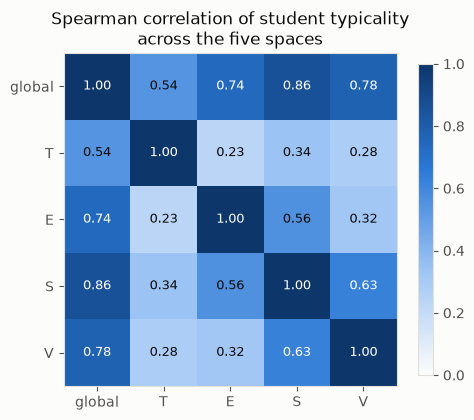

In [17]:

fig, ax = plt.subplots(figsize=(5, 4.5))
seq_cmap = mcolors.LinearSegmentedColormap.from_list('seq', ['#fcfcfb', '#9ec5f4', '#2a78d6', '#0d366b'])
im = ax.imshow(corr_df.values, cmap=seq_cmap, vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(spaces_list)
ax.set_yticks(range(5)); ax.set_yticklabels(spaces_list)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr_df.values[i,j]:.2f}', ha='center', va='center',
                color='white' if corr_df.values[i, j] > 0.6 else INK, fontsize=9)
ax.set_title('Spearman correlation of student typicality\nacross the five spaces')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()



**Typicality in T is nearly its own trait** — it correlates weakly with every
other space (0.23–0.54) — while **typicality in S correlates strongly with
global typicality (0.86)**, echoing the Section 6 finding from a completely
different angle (individual consistency, not community overlap): whatever
makes someone "typical" overall is closely tied to their standing on S, and
much less to their standing on T.


In [18]:

ranks = centrality.rank(ascending=False)
avg_rank = ranks.mean(axis=1).sort_values()
print('most consistently TYPICAL students (low average rank across all 5 spaces):')
display(centrality.loc[avg_rank.head(5).index].assign(avg_rank=avg_rank.head(5)))
print('\nmost consistently ATYPICAL / contrarian students (high average rank):')
display(centrality.loc[avg_rank.tail(5).index].assign(avg_rank=avg_rank.tail(5)))


most consistently TYPICAL students (low average rank across all 5 spaces):


,global,T,E,S,V,avg_rank
id,,,,,,
110,0.464428,0.395025,0.441791,0.502488,0.518408,7.2
105,0.465423,0.412935,0.461692,0.488557,0.498507,7.8
67,0.459950,0.394030,0.437811,0.499502,0.508458,9.8
114,0.458955,0.384080,0.469652,0.471642,0.510448,10.0
104,0.457214,0.382090,0.458706,0.489552,0.498507,11.3



most consistently ATYPICAL / contrarian students (high average rank):


,global,T,E,S,V,avg_rank
id,,,,,,
58,0.292040,0.381095,0.253731,0.261692,0.271642,56.9
65,0.330597,0.330348,0.333333,0.295522,0.363184,57.8
117,0.323383,0.308458,0.307463,0.288557,0.389055,59.2
22,0.297015,0.250746,0.340299,0.274627,0.322388,63.0
119,0.206468,0.339303,0.148259,0.169154,0.169154,63.8



Student **119** is the single most atypical student by this measure (lowest
typicality in global, E, S, *and* V) — the same student who landed in the
dissenting minority in **all five** signed-network splits in Section 9. Two
independent methods (correlation-clustering on signed edges, and plain average
similarity) agree on who the most consistent contrarian in this cohort is.


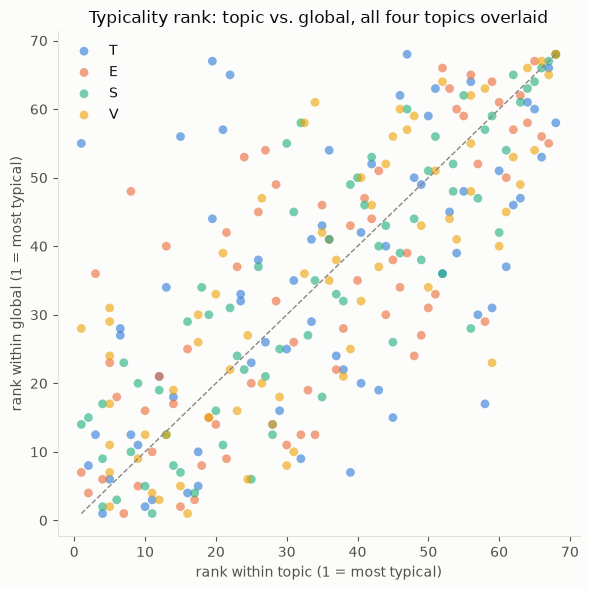

In [19]:

fig, ax = plt.subplots(figsize=(6, 6))
for i, t in enumerate(topics):
    ax.scatter(ranks[t], ranks['global'], color=TOPIC_COLOR[t], alpha=0.6, s=40, label=t, edgecolors='none')
ax.plot([1, N], [1, N], color=MUTED, linewidth=1, linestyle='--')
ax.set_xlabel('rank within topic (1 = most typical)')
ax.set_ylabel('rank within global (1 = most typical)')
ax.legend(frameon=False)
ax.set_title('Typicality rank: topic vs. global, all four topics overlaid')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()



S (green) and V (yellow) points hug the diagonal more closely than T (blue),
which scatters widely above and below it — the same S/V-vs-T pattern as
Section 6, now visible at the level of individual students rather than
communities.



## 11. Summary of findings

1. **Agreement-rate similarity shows S (society/ethics) and V (environment)
   topic communities matching the global community far more than T (AI/tech)
   and E (education) do.** This holds under all three graph-building
   strategies (full, k-NN, threshold) and at the individual level (Section 10's
   typicality correlations), though the *strength* of the effect is largest on
   the full, unsparsified graph (ARI 0.62 / 0.78) and weaker once sparsified
   (Section 6).
2. That gap tracks a **consensus/ceiling effect**: V and S have much lower item
   variance than T and E (Section 7), so there's less topic-specific signal to
   diverge from a general disposition in the first place.
3. **The similarity-based communities are not opposing camps** — under a
   structural-balance measure they score at chance level (Section 9). Real
   polarization does exist, but it's a different structure: a small (10–15
   student), fairly consistent dissenting minority versus everyone else, not a
   roughly-even split.
4. **Two students (109, 119) are the cohort's most consistent contrarians**,
   identified independently by both the signed-network minority analysis and
   the plain typicality/centrality measure (Sections 9–10).
5. **Pearson correlation is the least reliable metric for community
   comparisons**, because it produces isolated "communities of one" out of
   students who rated an entire topic block identically — common on the
   low-variance V/S topics — regardless of whether the graph is sparsified.
6. **Cosine similarity only becomes informative once the graph is sparsified**:
   on the full graph every cosine similarity is positive and fairly uniform, so
   Louvain finds no contrast to split on; k-NN/threshold restore contrast by
   keeping only each node's relatively strongest ties.



## 12. Other graph ideas worth trying next (not yet built)

Hypotheses and possible next analyses, for discussion before building any of
them:

- **Controversy-only subgraph.** Rebuild the global similarity using only the
  highest-variance items (drop near-unanimous items entirely) — would this
  sharpen or change the communities found here?
- **Item-item graph.** The dual construction — nodes are the 60 questions,
  edges are their correlation across students — would test whether the
  survey's own T/E/S/V labeling matches the data's latent opinion structure at
  all, independent of the student-level analysis above.
- **Response-style / acquiescence clustering.** A graph built on each
  student's own rating *style* (mean, variance, extremity) rather than content
  agreement, to check whether part of the "general disposition" effect in
  Section 7 is really just some students using the scale more extremely than
  others.
- **Resolution sweep.** Everything above used Louvain's default resolution
  (1.0); a sweep (e.g. 0.5–2.0) would show whether the "S/V persist, T/E don't"
  finding survives at coarser or finer community granularity.

Let me know which of these (if any) you'd like built out.
